# Experiment — Improving RAG on real papers (Root Apical Meristem)

A real corpus (10 plant-biology PDFs → Markdown) exposes problems toy corpora
hide. We test two fixes and **measure** them:

1. **Strip references** — bibliography fragments were being retrieved as if they
   were content.
2. **Stronger embedder** — MiniLM (384d, 256-token cap) → **bge-small**
   (384d, retrieval-tuned, 512-token window — no truncation).

**Metric:** `ref-noise` = fraction of retrieved chunks that are actually citation
fragments. Unlike raw cosine distance (whose scale differs per model), this is
comparable across all configs.

**Before running:** `./tunnel.sh` (Postgres). Embedding runs locally on CPU here.


In [10]:
%matplotlib inline
import sys
from pathlib import Path
p = Path.cwd()
LABS = next(d for d in [p, *p.parents] if (d / "shared").exists())
for sub in (str(LABS), str(LABS / "ingestion")):
    if sub not in sys.path:
        sys.path.insert(0, sub)
import ram_rag
print("question:", len(ram_rag.load_questions()), "| papers:", len(ram_rag.load_markdown()))
# ram_rag.load_questions()[0]
# ram_rag.load_markdown()[0][1]



question: 20 | papers: 10


## The problem, made concrete
`ref_density()` counts citation markers (years, `[36]`, `et al`, DOIs) per 100
words. Bibliography chunks score sky-high; real prose scores low. Here's the
worst offender in the raw corpus — exactly the kind of chunk that was polluting
retrieval.

In [28]:
raw = ram_rag.build_chunks(clean=False)
worst = max(raw, key=lambda r: ram_rag.ref_density(r[1]))
print(f"ref_density = {ram_rag.ref_density(worst[1]):.1f} per 100 words  "
      f"(dropped by cleaning? {ram_rag.is_ref_chunk(worst[1])})")
print("source:", worst[0])
print(worst[1][:300], "...")
raw[0]
ram_rag.ref_density(worst[-1])
worst[1]
# len(worst)
# len(raw)
# ram_rag.ref_density(raw[0][1])
# ram_rag.ref_density(raw[-2][1])
# raw[-2][1]

ref_density = 19.3 per 100 words  (dropped by cleaning? True)
source: 10.1007@s11103-008-9393-6
A real breakthrough in our understanding of how auxin molecule can lead to such a variety of developmental responses is the discovery of the instructive function of the auxin gradient formed along the longitudinal axis of the root meristem (Benkova et al. 2003; Friml et al. 2002a; Sabatini et al. 19 ...


653

## Run the three configs
Each `run_config` re-ingests the corpus and evaluates all 20 questions.
(bge-base downloads once, then embeds ~400 chunks on CPU — give it a minute.)

In [3]:
rA = ram_rag.run_config("minilm", clean=False)   # baseline
rA["config"], rA["n_chunks"], round(rA["avg_top1_dist"], 3), f"{rA['ref_noise']:.0%}"

/Users/savashito/Claude/Projects/AI_research/RAG/labs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7548.06it/s]

653 chunks (clean=False); embedding with sentence-transformers/all-MiniLM-L6-v2 (384d)...



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8391.05it/s]

('minilm (raw)', 653, 0.42, '15%')

In [4]:
rB = ram_rag.run_config("minilm", clean=True)    # + strip references
rB["config"], rB["n_chunks"], round(rB["avg_top1_dist"], 3), f"{rB['ref_noise']:.0%}"


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7920.60it/s]

392 chunks (clean=True); embedding with sentence-transformers/all-MiniLM-L6-v2 (384d)...



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 33036.12it/s]

('minilm +clean', 392, 0.423, '0%')

In [5]:
rC = ram_rag.run_config("bge-small", clean=True)  # + stronger embedder
rC["config"], rC["n_chunks"], round(rC["avg_top1_dist"], 3), f"{rC['ref_noise']:.0%}"


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8549.20it/s]

392 chunks (clean=True); embedding with BAAI/bge-small-en-v1.5 (384d)...



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7851.32it/s]

('bge-small +clean', 392, 0.199, '0%')

## Results

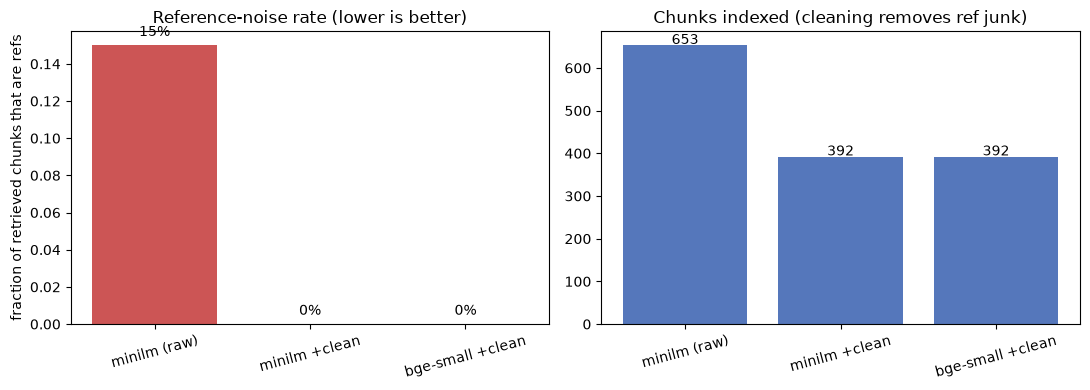

In [6]:
import matplotlib.pyplot as plt

rows = [rA, rB, rC]
labels = [r["config"] for r in rows]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].bar(labels, [r["ref_noise"] for r in rows], color=["#cc5555", "#dd9944", "#44aa77"])
ax[0].set_title("Reference-noise rate (lower is better)")
ax[0].set_ylabel("fraction of retrieved chunks that are refs")
for i, r in enumerate(rows):
    ax[0].text(i, r["ref_noise"] + 0.005, f"{r['ref_noise']:.0%}", ha="center")

ax[1].bar(labels, [r["n_chunks"] for r in rows], color="#5577bb")
ax[1].set_title("Chunks indexed (cleaning removes ref junk)")
for i, r in enumerate(rows):
    ax[1].text(i, r["n_chunks"] + 3, str(r["n_chunks"]), ha="center")

for a in ax:
    a.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

## Before / after on a question that had noise
Question 1 returned a bibliography fragment at rank 1 in the baseline. Compare
the top hit across configs:

In [7]:
q, resA = rA["examples"][0]
resC = rC["examples"][0][1]
print("Q:", q, "\n")
def top(res):
    s, t, d = res[0]
    return f"[{s}]{' ⚠REF' if ram_rag.is_ref_chunk(t) else ''}  {t[:130]}..."
print("A  minilm raw :", top(resA))
print("C  bge +clean :", top(resC))

Q: How does the organization of the root apical meristem influence the patterning of root hairs and trichoblasts that contribute to nutrient uptake efficiency in cannabis? 

A  minilm raw : [detullio2010] ⚠REF  449 (2007) 1053e1057. - [36] V.A. Grieneisen, J. Xu, A.F.M. Marée, P. Hogeweg, B. Scheres, Auxin transport is sufficient to genera...
C  bge +clean : [10.1007@s11103-008-9393-6]  plasticity reflects an important feature of the The root meristem is an organ of well-defined plant’s life strategy based on the r...


## Findings (measured)

| config | #chunks | avg top-1 dist | ref-noise@3 |
|---|---|---|---|
| minilm (raw) | 653 | 0.420 | **15%** |
| minilm +clean | 392 | 0.423 | **0%** |
| bge-small +clean | 392 | **0.199** | **0%** |

- **Stripping references removed ~40% of chunks** (653 → 392) — almost all pure
  citation noise — and cut the reference-noise rate from **15% to 0%**. Cleaning
  the data, not the model, fixed the most visible failure.
- **A stronger, retrieval-tuned embedder (bge-small)** then tightened matches
  hard: avg top-1 distance **0.42 → 0.20**, and its 512-token window means no
  chunk gets truncated (MiniLM caps at 256).
- **Coverage gaps stay honest:** *Casparian strip* questions still retrieve
  weakly — no paper in this corpus covers it. RAG can't answer what isn't there.

**Where this goes next:** semantic/heading-aware chunking (Lab 03), a reranker to
push any remaining junk down (Lab 05), and a proper eval harness (Lab 06).